## Step 1 – Install Required Libraries

In [ ]:
# Install dependencies (run once)
import subprocess, sys

packages = [
    'requests',
    'beautifulsoup4',
    'lxml',
    'langdetect',
    'pandas',
    'tqdm'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed successfully.')

# Here I am installing required packages for web scraping and data processing


All packages installed successfully.


In [ ]:
import requests
from bs4 import BeautifulSoup
import re
import time
import json
import pandas as pd
from langdetect import detect, LangDetectException
from tqdm import tqdm
import unicodedata
import os
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully.')

# Here I am importing all necessary libraries for web scraping, data processing, and visualization


Libraries imported successfully.


In [ ]:
# ──────────────────────────────────────────────────────────────
# 3.1  HTTP fetch with retry & polite delay
# ──────────────────────────────────────────────────────────────
HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
}

def fetch_page(url: str, retries: int = 3, delay: float = 1.5) -> BeautifulSoup | None:
    """Fetch a URL and return a BeautifulSoup object. Returns None on failure."""
    for attempt in range(retries):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=20)
            resp.raise_for_status()
            time.sleep(delay)          # polite crawling
            return BeautifulSoup(resp.text, 'lxml')
        except Exception as e:
            print(f'  [Attempt {attempt+1}] Error fetching {url}: {e}')
            time.sleep(delay * (attempt + 1))
    return None

# ──────────────────────────────────────────────────────────────
# 3.2  Text extraction – visible text only, strip scripts/styles
# ──────────────────────────────────────────────────────────────
REMOVE_TAGS = {'script', 'style', 'noscript', 'head', 'meta', 'link',
               'footer', 'nav', 'header', 'aside'}

def extract_text(soup: BeautifulSoup) -> str:
    """Extract clean visible text from a BeautifulSoup object."""
    if soup is None:
        return ''
    for tag in soup.find_all(REMOVE_TAGS):
        tag.decompose()
    text = soup.get_text(separator=' ')
    # collapse whitespace
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{2,}', '\n', text)
    return text.strip()

# ──────────────────────────────────────────────────────────────
# 3.3  Language filtering – keep only English sentences
# ──────────────────────────────────────────────────────────────
def is_english(text: str, min_len: int = 20) -> bool:
    """Return True if the text is detected as English."""
    text = text.strip()
    if len(text) < min_len:
        return True          # too short to reliably detect; keep it
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False

def filter_english_sentences(raw_text: str) -> str:
    """
    Split raw text into lines/sentences, keep only English ones.
    Also removes lines composed entirely of non-ASCII / Devanagari characters.
    """
    lines = raw_text.splitlines()
    english_lines = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        # Quick heuristic: skip lines where >50% chars are non-ASCII
        ascii_ratio = sum(1 for c in line if ord(c) < 128) / max(len(line), 1)
        if ascii_ratio < 0.5:
            continue
        if is_english(line):
            english_lines.append(line)
    return '\n'.join(english_lines)

# ──────────────────────────────────────────────────────────────
# 3.4  Deduplication
# ──────────────────────────────────────────────────────────────
def deduplicate_lines(text: str) -> str:
    """Remove duplicate lines while preserving order."""
    seen = set()
    unique = []
    for line in text.splitlines():
        if line not in seen:
            seen.add(line)
            unique.append(line)
    return '\n'.join(unique)

print('Helper utilities defined.')

# Here I am defining HTTP fetch, text extraction, language filtering, and deduplication functions


Helper utilities defined.


In [ ]:
SOURCE1_URLS = [
    # Home page
    'https://iitj.ac.in',
    # Research highlights
    'https://iitj.ac.in/main/en/research-highlight',
    # About IIT Jodhpur
    'https://iitj.ac.in/main/en/about-iit-jodhpur',
    # Vision & Mission
    'https://iitj.ac.in/main/en/vision-and-mission',
    # Admissions overview
    'https://iitj.ac.in/admission-postgraduate-programs/en/admissions',
    # PhD Admissions
    'https://iitj.ac.in/admission-postgraduate-programs/en/phd-admissions',
    # Campus & Infrastructure
    'https://iitj.ac.in/main/en/campus',
    # Placements
    'https://iitj.ac.in/main/en/placements',
    # International Relations
    'https://iitj.ac.in/international-relations/en/international-relations',
    # Student Activities
    'https://iitj.ac.in/student-activity/en/student-activity',
    # Alumni
    'https://iitj.ac.in/alumni-affairs/en/alumni-affairs',
    # Events
    'https://iitj.ac.in/main/en/events',
    # Library
    'https://iitj.ac.in/library/en/library',
    # Innovation & Entrepreneurship
    'https://iitj.ac.in/innovation-entrepreneurship/en/innovation-entrepreneurship',
    # Hostel & Residential Life
    'https://iitj.ac.in/hostel/en/hostel',
]

source1_texts = []

for url in tqdm(SOURCE1_URLS, desc='Source 1Main Website'):
    soup = fetch_page(url)
    if soup:
        raw = extract_text(soup)
        clean = filter_english_sentences(raw)
        clean = deduplicate_lines(clean)
        source1_texts.append({'url': url, 'text': clean, 'len': len(clean)})
        print(f'  ✔ {url}  ({len(clean):,} chars)')
    else:
        print(f'  ✘ Failed: {url}')

source1_combined = '\n\n'.join(d['text'] for d in source1_texts)
print(f'\nTotal Source 1 text length: {len(source1_combined):,} characters')

# Here I am collecting and cleaning data from IITJ main website portal including research, admissions, placements, events, and campus information


Source 1Main Website:   7%|▋         | 1/15 [00:03<00:55,  3.99s/it]

  ✔ https://iitj.ac.in  (3,498 chars)


Source 1Main Website:  13%|█▎        | 2/15 [00:07<00:48,  3.76s/it]

  ✔ https://iitj.ac.in/main/en/research-highlight  (1,337 chars)


Source 1Main Website:  20%|██        | 3/15 [00:09<00:34,  2.87s/it]

...

  ✔ https://iitj.ac.in/library/en/library  (43 chars)


Source 1Main Website:  93%|█████████▎| 14/15 [00:35<00:02,  2.37s/it]

  ✔ https://iitj.ac.in/innovation-entrepreneurship/en/innovation-entrepreneurship  (43 chars)


Source 1Main Website: 100%|██████████| 15/15 [00:36<00:00,  2.47s/it]

  ✔ https://iitj.ac.in/hostel/en/hostel  (43 chars)

Total Source 1 text length: 10,913 characters


In [ ]:
SOURCE2_URLS = [
    # Institute Repository – Academic Regulations index
    'https://iitj.ac.in/Institute-Repository/en/Institute-Repository',
    # Academic regulations
    'https://iitj.ac.in/office-of-academics/en/academic-regulations',
    # UG Academic Regulations
    'https://iitj.ac.in/Institute-Repository/en/academic-regulations-ug',
    # PG Academic Regulations
    'https://iitj.ac.in/Institute-Repository/en/academic-regulations-pg',
    # PhD Regulations
    'https://iitj.ac.in/Institute-Repository/en/academic-regulations-phd',
    # Academic Calendar
    'https://iitj.ac.in/academic-calendar/en/academic-calendar',
    # Office of Academics
    'https://iitj.ac.in/office-of-academics/en/office-of-academics',
    # Office of Research & Development
    'https://iitj.ac.in/research-development/en/research-development',
    # Sponsored Research & Consultancy
    'https://iitj.ac.in/research-development/en/sponsored-research',
    # Examination & Evaluation
    'https://iitj.ac.in/office-of-academics/en/examination',
    # Scholarships & Financial Aid
    'https://iitj.ac.in/student-welfare/en/scholarships',
]

source2_texts = []

for url in tqdm(SOURCE2_URLS, desc='Source 2 Academic Regulations'):
    soup = fetch_page(url)
    if soup:
        raw = extract_text(soup)
        clean = filter_english_sentences(raw)
        clean = deduplicate_lines(clean)
        source2_texts.append({'url': url, 'text': clean, 'len': len(clean)})
        print(f'  ✔ {url}  ({len(clean):,} chars)')
    else:
        print(f'  ✘ Failed: {url}')

source2_combined = '\n\n'.join(d['text'] for d in source2_texts)
print(f'\nTotal Source 2 text length: {len(source2_combined):,} characters')

# Here I am collecting and cleaning data from academic regulations, calendar, research guidelines, and scholarship pages


Source 2 Academic Regulations:   9%|▉         | 1/11 [00:02<00:25,  2.51s/it]

  ✔ https://iitj.ac.in/Institute-Repository/en/Institute-Repository  (770 chars)


Source 2 Academic Regulations:  18%|█▊        | 2/11 [00:08<00:41,  4.57s/it]

  ✔ https://iitj.ac.in/office-of-academics/en/academic-regulations  (91,381 chars)


Source 2 Academic Regulations:  27%|██▋       | 3/11 [00:10<00:26,  3.30s/it]

...

  ✔ https://iitj.ac.in/research-development/en/sponsored-research  (43 chars)


Source 2 Academic Regulations:  91%|█████████ | 10/11 [00:23<00:01,  1.94s/it]

  ✔ https://iitj.ac.in/office-of-academics/en/examination  (43 chars)


Source 2 Academic Regulations: 100%|██████████| 11/11 [00:25<00:00,  2.30s/it]

  ✔ https://iitj.ac.in/student-welfare/en/scholarships  (43 chars)

Total Source 2 text length: 92,558 characters


In [ ]:
DEPARTMENT_SLUGS = {
    'Computer Science & Engineering':  'cse',
    'Electrical Engineering':          'ee',
    'Mechanical Engineering':          'me',
    'Civil & Infrastructure Engg':     'cie',
    'Bioscience & Biomedical Engg':    'bbe',
    'Mathematics':                     'math',
    'Physics':                         'physics',
    'Chemistry':                       'chemistry',
    'Humanities & Social Sciences':    'hss',
}

BASE_DEPT = 'https://iitj.ac.in/{slug}/en/{slug}'

# Additional per-department sub-pages (research, courses, labs)
DEPT_EXTRA_URLS = [
    # CSE sub-pages
    ('https://iitj.ac.in/cse/en/research', 'CSE – Research'),
    ('https://iitj.ac.in/cse/en/courses', 'CSE – Courses'),
    ('https://iitj.ac.in/cse/en/labs', 'CSE – Labs'),
    # EE sub-pages
    ('https://iitj.ac.in/ee/en/research', 'EE – Research'),
    ('https://iitj.ac.in/ee/en/courses', 'EE – Courses'),
    # ME sub-pages
    ('https://iitj.ac.in/me/en/research', 'ME – Research'),
    ('https://iitj.ac.in/me/en/courses', 'ME – Courses'),
    # Physics sub-pages
    ('https://iitj.ac.in/physics/en/research', 'Physics – Research'),
    ('https://iitj.ac.in/physics/en/courses', 'Physics – Courses'),
    # Chemistry sub-pages
    ('https://iitj.ac.in/chemistry/en/research', 'Chemistry – Research'),
    ('https://iitj.ac.in/chemistry/en/courses', 'Chemistry – Courses'),
    # Math sub-pages
    ('https://iitj.ac.in/math/en/research', 'Math – Research'),
    ('https://iitj.ac.in/math/en/courses', 'Math – Courses'),
    # HSS sub-pages
    ('https://iitj.ac.in/hss/en/research', 'HSS – Research'),
    ('https://iitj.ac.in/hss/en/courses', 'HSS – Courses'),
]


source3_texts = []

for dept_name, slug in tqdm(DEPARTMENT_SLUGS.items(), desc='Source 3 – Departments'):
    url = BASE_DEPT.format(slug=slug)
    soup = fetch_page(url)
    if soup:
        raw = extract_text(soup)
        clean = filter_english_sentences(raw)
        clean = deduplicate_lines(clean)
        source3_texts.append({'department': dept_name, 'url': url, 'text': clean, 'len': len(clean)})
        print(f'  ✔ {dept_name:<40}  ({len(clean):,} chars)')
    else:
        print(f'  ✘ Failed: {dept_name} - {url}')

for url, label in tqdm(DEPT_EXTRA_URLS, desc='Source 3 – Dept Sub-pages'):
    soup = fetch_page(url)
    if soup:
        raw = extract_text(soup)
        clean = filter_english_sentences(raw)
        clean = deduplicate_lines(clean)
        source3_texts.append({'department': label, 'url': url, 'text': clean, 'len': len(clean)})
        print(f'  ✔ {label:<40}  ({len(clean):,} chars)')
    else:
        print(f'  ✘ Failed: {label} - {url}')

source3_combined = '\n\n'.join(d['text'] for d in source3_texts)
print(f'\nTotal Source 3 text length: {len(source3_combined):,} characters')

# Here I am scraping data from all 9 departments and their research, courses, and labs sub-pages


Source 3 – Departments:  11%|█         | 1/9 [00:01<00:14,  1.84s/it]

  ✔ Computer Science & Engineering            (43 chars)


Source 3 – Departments:  22%|██▏       | 2/9 [00:03<00:12,  1.83s/it]

  ✔ Electrical Engineering                    (43 chars)


Source 3 – Departments:  33%|███▎      | 3/9 [00:05<00:10,  1.83s/it]

...

  ✔ Math – Courses                            (43 chars)


Source 3 – Dept Sub-pages:  93%|█████████▎| 14/15 [00:29<00:02,  2.11s/it]

  ✔ HSS – Research                            (43 chars)


Source 3 – Dept Sub-pages: 100%|██████████| 15/15 [00:31<00:00,  2.08s/it]

  ✔ HSS – Courses                             (43 chars)

Total Source 3 text length: 15,985 characters


In [ ]:
SOURCE4_URLS = [
    'https://iitj.ac.in/cse/en/people',
    'https://iitj.ac.in/ee/en/people',
    'https://iitj.ac.in/me/en/people',
    'https://iitj.ac.in/physics/en/people',
    'https://iitj.ac.in/math/en/people',
    'https://iitj.ac.in/chemistry/en/people',
    'https://iitj.ac.in/hss/en/people',
    # Additional departments
    'https://iitj.ac.in/cie/en/people',
    'https://iitj.ac.in/bbe/en/people',
    # School / Centre pages
    'https://iitj.ac.in/management-studies/en/people',
    'https://iitj.ac.in/desn/en/people',
]

source4_texts = []

for url in tqdm(SOURCE4_URLS, desc='Source 4 – Faculty Pages'):
    soup = fetch_page(url)
    if soup:
        raw = extract_text(soup)
        clean = filter_english_sentences(raw)
        clean = deduplicate_lines(clean)
        source4_texts.append({'url': url, 'text': clean, 'len': len(clean)})
        print(f'  ✔ {url}  ({len(clean):,} chars)')
    else:
        print(f'  ✘ Failed: {url}')

source4_combined = '\n\n'.join(d['text'] for d in source4_texts)
print(f'\nTotal Source 4 text length: {len(source4_combined):,} characters')

# Here I am collecting faculty and people data from all departments and research centers


Source 4 – Faculty Pages:   9%|▉         | 1/11 [00:01<00:18,  1.89s/it]

  ✔ https://iitj.ac.in/cse/en/people  (43 chars)


Source 4 – Faculty Pages:  18%|█▊        | 2/11 [00:03<00:16,  1.85s/it]

  ✔ https://iitj.ac.in/ee/en/people  (43 chars)


Source 4 – Faculty Pages:  27%|██▋       | 3/11 [00:05<00:14,  1.85s/it]

...

  ✔ https://iitj.ac.in/bbe/en/people  (43 chars)


Source 4 – Faculty Pages:  91%|█████████ | 10/11 [00:18<00:01,  1.88s/it]

  ✔ https://iitj.ac.in/management-studies/en/people  (43 chars)


Source 4 – Faculty Pages: 100%|██████████| 11/11 [00:20<00:00,  1.87s/it]

  ✔ https://iitj.ac.in/desn/en/people  (43 chars)

Total Source 4 text length: 493 characters


In [ ]:
SOURCE5_URLS = [
    'https://iitj.ac.in/techscape/en/Techscape',
    'https://iitj.ac.in/main/en/announcements',
    # Press releases / media
    'https://iitj.ac.in/main/en/media',
    # IITJ in news
    'https://iitj.ac.in/main/en/iitj-in-news',
    # Circulars
    'https://iitj.ac.in/main/en/circulars',
    # Tenders & Notices
    'https://iitj.ac.in/main/en/tenders',
    # Awards & Achievements
    'https://iitj.ac.in/main/en/awards-and-achievements',
]

source5_texts = []

for url in tqdm(SOURCE5_URLS, desc='Source 5 – Newsletters & Circulars'):
    soup = fetch_page(url)
    if soup:
        raw = extract_text(soup)
        clean = filter_english_sentences(raw)
        clean = deduplicate_lines(clean)
        source5_texts.append({'url': url, 'text': clean, 'len': len(clean)})
        print(f'  ✔ {url}  ({len(clean):,} chars)')
    else:
        print(f'  ✘ Failed: {url}')

source5_combined = '\n\n'.join(d['text'] for d in source5_texts)
print(f'\nTotal Source 5 text length: {len(source5_combined):,} characters')

# Here I am gathering announcements, press releases, news, circulars, tenders, and awards information


Source 5 – Newsletters & Circulars:  14%|█▍        | 1/7 [00:02<00:14,  2.45s/it]

  ✔ https://iitj.ac.in/techscape/en/Techscape  (2,908 chars)


Source 5 – Newsletters & Circulars:  29%|██▊       | 2/7 [00:04<00:10,  2.09s/it]

  ✔ https://iitj.ac.in/main/en/announcements  (43 chars)


Source 5 – Newsletters & Circulars:  43%|████▎     | 3/7 [00:06<00:07,  1.98s/it]

...

  ✔ https://iitj.ac.in/main/en/circulars  (43 chars)


Source 5 – Newsletters & Circulars:  86%|████████▌ | 6/7 [00:11<00:01,  1.94s/it]

  ✔ https://iitj.ac.in/main/en/tenders  (43 chars)


Source 5 – Newsletters & Circulars: 100%|██████████| 7/7 [00:13<00:00,  1.97s/it]

  ✔ https://iitj.ac.in/main/en/awards-and-achievements  (43 chars)

Total Source 5 text length: 3,178 characters


In [ ]:
all_records = []

# --- Source 1 ---
for d in source1_texts:
    all_records.append({'source_id': 1, 'source_name': 'Main Website',
                        'url': d['url'], 'text': d['text']})

# --- Source 2 ---
for d in source2_texts:
    all_records.append({'source_id': 2, 'source_name': 'Academic Regulations',
                        'url': d['url'], 'text': d['text']})

# --- Source 3 ---
for d in source3_texts:
    label = d.get('department', d['url'])
    all_records.append({'source_id': 3, 'source_name': f'Department – {label}',
                        'url': d['url'], 'text': d['text']})

# --- Source 4 ---
for d in source4_texts:
    all_records.append({'source_id': 4, 'source_name': 'Faculty Profiles',
                        'url': d['url'], 'text': d['text']})

# --- Source 5 ---
for d in source5_texts:
    all_records.append({'source_id': 5, 'source_name': 'Newsletter / Circulars',
                        'url': d['url'], 'text': d['text']})

df = pd.DataFrame(all_records)
df['char_count'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda t: len(t.split()))

print(df[['source_id', 'source_name', 'url', 'char_count', 'word_count']].to_string(index=False))
print(f'\n=== TOTAL RECORDS: {len(df)} ===')
print(f'=== TOTAL WORDS  : {df["word_count"].sum():,} ===')
print(f'=== TOTAL CHARS  : {df["char_count"].sum():,} ===')

# Here I am aggregating all collected source data into a unified DataFrame with metadata and computing character and word counts


 source_id                                 source_name                                                                           url  char_count  word_count
         1                                Main Website                                                            https://iitj.ac.in        3498         501
         1                                Main Website                                 https://iitj.ac.in/main/en/research-highlight        1337         181
         1                                Main Website                                  https://iitj.ac.in/main/en/about-iit-jodhpur          43           9
         1                                Main Website                                 https://iitj.ac.in/main/en/vision-and-mission        3978         525
         1                                Main Website              https://iitj.ac.in/admission-postgraduate-programs/en/admissions          43           9
         1                                Main Website    

In [ ]:
summary = df.groupby(['source_id', 'source_name']).agg(
    pages=('url', 'count'),
    total_chars=('char_count', 'sum'),
    total_words=('word_count', 'sum')
).reset_index()

print('\n=== Per-Source Summary ===')
print(summary.to_string(index=False))

print('\n=== Overall Statistics ===')
print(f'  Total sources   : {summary.shape[0]}')
print(f'  Total pages     : {summary["pages"].sum()}')
print(f'  Total words     : {summary["total_words"].sum():,}')
print(f'  Total characters: {summary["total_chars"].sum():,}')

# Here I am computing per-source summary statistics for number of pages, total characters, and total words



=== Per-Source Summary ===
 source_id                                 source_name  pages  total_chars  total_words
         1                                Main Website     15        10885         1531
         2                        Academic Regulations     11        92538        14327
         3   Department – Bioscience & Biomedical Engg      1           43            9
         3                  Department – CSE – Courses      1           43            9
         3                     Department – CSE – Labs      1           43            9
         3                 Department – CSE – Research      1           43            9
         3                      Department – Chemistry      1         4687          669
         3            Department – Chemistry – Courses      1         2510          352
         3           Department – Chemistry – Research      1           43            9
         3    Department – Civil & Infrastructure Engg      1           43            9
    

In [ ]:
OUTPUT_DIR = 'data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. CSV
csv_path = os.path.join(OUTPUT_DIR, 'iitj_corpus.csv')
df.to_csv(csv_path, index=False, encoding='utf-8')
print(f'CSV saved   → {csv_path}')

# 2. JSON
json_path = os.path.join(OUTPUT_DIR, 'iitj_corpus.json')
df.to_json(json_path, orient='records', indent=2, force_ascii=False)
print(f'JSON saved  → {json_path}')

# 3. Plain text (all sources merged)
txt_path = os.path.join(OUTPUT_DIR, 'iitj_corpus.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    for _, row in df.iterrows():
        f.write(f'=== SOURCE: {row["source_name"]} | URL: {row["url"]} ===\n')
        f.write(row['text'])
        f.write('\n\n')
print(f'TXT saved   → {txt_path}')

print('\nAll files saved successfully!')

# Here I am exporting the raw collected corpus to CSV, JSON, and plain text formats


CSV saved   → data\iitj_corpus.csv
JSON saved  → data\iitj_corpus.json
TXT saved   → data\iitj_corpus.txt

All files saved successfully!


In [ ]:
print('=== PREVIEW: First 1500 characters from each source ===\n')

for src_id in range(1, 6):
    subset = df[df['source_id'] == src_id]
    if subset.empty:
        print(f'--- Source {src_id}: No data collected ---\n')
        continue
    src_name = subset.iloc[0]['source_name']
    combined = ' '.join(subset['text'].tolist())
    print(f'--- Source {src_id}: {src_name} ---')
    print(combined[:1500])
    print('...\n')

# Here I am displaying a preview of the first 1500 characters from each collected source


=== PREVIEW: First 1500 characters from each source ===

--- Source 1: Main Website ---
###147852369$$$_RedirectToLoginPage_%%%963258741!!!
About IIT Jodhpur
Indian Institute of Technology Jodhpur was established in 2008, to foster technology education and research in India. The Institute is committed to technological thought and action to benefit the economic development of India. Scholarship in teaching and learning; Scholarship in research and creative accomplishments; and relevance to Industry are three driving forces for us at IIT Jodhpur. IIT Jodhpur functions from its sprawling residential Permanent Campus of 852 acres on National Highway 65, north-northwest of Jodhpur towards Nagaur. This campus is meticulously planned and envisioned to stand as a symbol of academics – simple, but deep.
Discover More about IITJ
Highlight
View All Highlights
Imaging atomic-scale magnetism with energy-filtered differential phase contrast method
Structure and exfoliation mechanism of two-dimension

In [ ]:
import subprocess, sys

extra_pkgs = ['nltk', 'wordcloud', 'matplotlib']
for pkg in extra_pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('Preprocessing dependencies ready.')

# Here I am installing and downloading preprocessing dependencies for tokenization and visualization


Preprocessing dependencies ready.


In [ ]:
import pandas as pd
import os

df = pd.read_csv('data/iitj_corpus.csv')
print(f'Loaded {len(df)} documents from CSV.')
print(f'Columns: {list(df.columns)}')
print(f'\nRaw total words: {df["word_count"].sum():,}')

# Here I am loading the raw corpus from CSV and displaying basic dataset information


Loaded 68 documents from CSV.
Columns: ['source_id', 'source_name', 'url', 'text', 'char_count', 'word_count']

Raw total words: 18,748


In [ ]:
import re

# ── Exact boilerplate strings / nav items to drop (lowercase match) ──
BOILERPLATE_LINES = {
    '###147852369$$$_redirecttologinpage_%%%963258741!!!',
    'important links', 'cccd @ iitj', 'recruitment', 'correspondence',
    'rti', 'tenders', 'techscape', 'contact', 'old website', 'nccr portal',
    'how to reach iitj', 'institute repository', 'donations', 'web policy',
    'web information manager', 'feedback', 'cert-in', 'help', 'nirf',
    'internal committee', 'intranet links', 'page/file not found',
    '... go to home page ...', 'accessibility', 'ariia 2019-20',
    'vanguard lectures', 'minutes of senate meeting', 'minutes of bog meeting',
    'annual report', 'newsletter', 'brochure', 'archive',
    'view all highlights', 'view all news', 'view all announcements',
    'view all events', 'view current issue', 'lhb booking',
    'discover more about iitj', 'discover more about student life at iitj',
    'key functionaries', 'chairman, bog', 'director',
    'latest news', 'announcement', 'event', 'highlight', 'highlights',
    'programs', 'seminars & meetings', 'quick links', 'journal information',
    'title', 'frequency', 'aim and scope', 'sr. no.', 'description',
    'research areas', 'collaborations', 'infrastructure', 'latest events',
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec',
    '2024', '2025', '2026',
}

# ── Regex patterns ────────────────────────────────────────────
_URL_RE    = re.compile(r'https?://\S+')
_SIZE_RE   = re.compile(r'\(\s*\d+(?:\.\d+)?\s*[KMG]?B\s*\)')
_ARROW_RE  = re.compile(r'arrow_downward\s*[\U0001f000-\U0001ffff\u2000-\u2fff]*', re.UNICODE)
_COPY_RE   = re.compile(r'copyright\s*.*', re.IGNORECASE)
_LASTUPDRE = re.compile(r'last updated\s*:.*', re.IGNORECASE)
_EMAIL_RE  = re.compile(r'for any comments.*email.*', re.IGNORECASE)
_NHEADER   = re.compile(r'n\.h\.\s*\d+.*rajasthan.*', re.IGNORECASE)
_ACK_CHK   = re.compile(r'academics<<.*', re.IGNORECASE)

def remove_boilerplate(text: str) -> str:
    """Apply all boilerplate removal rules to a single document string."""
    cleaned_lines = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        line = _URL_RE.sub('', line).strip()
        line = _SIZE_RE.sub('', line).strip()
        line = _ARROW_RE.sub('', line).strip()
        if any(p.search(line) for p in [_COPY_RE, _LASTUPDRE, _EMAIL_RE,
                                         _NHEADER, _ACK_CHK]):
            continue
        if line.lower() in BOILERPLATE_LINES:
            continue
        if re.match(r'^\d+$', line):
            continue
        if len(line) <= 2:
            continue
        if line:
            cleaned_lines.append(line)
    return '\n'.join(cleaned_lines)

df['text_no_boilerplate'] = df['text'].apply(remove_boilerplate)

before = df['text'].apply(len).sum()
after  = df['text_no_boilerplate'].apply(len).sum()
print(f'Characters BEFORE boilerplate removal : {before:,}')
print(f'Characters AFTER  boilerplate removal : {after:,}')
print(f'Reduction                             : {100*(before-after)/before:.1f}%')

# Here I am removing navigation items, copyright notices, URLs, and other website boilerplate from the raw text


Characters BEFORE boilerplate removal : 123,001
Characters AFTER  boilerplate removal : 112,681
Reduction                             : 8.4%


In [ ]:
from nltk.tokenize import word_tokenize

def tokenize_and_lowercase(text: str) -> list:
    """Tokenize with NLTK and lowercase all tokens."""
    tokens = word_tokenize(text)
    return [t.lower() for t in tokens]

df['tokens_raw'] = df['text_no_boilerplate'].apply(tokenize_and_lowercase)

total_raw_tokens = df['tokens_raw'].apply(len).sum()
print(f'Total tokens after tokenization & lowercasing: {total_raw_tokens:,}')
print(f'\nSample tokens (first 30 from document 1):')
print(df['tokens_raw'].iloc[0][:30])

# Here I am tokenizing the boilerplate-removed text using NLTK and converting all tokens to lowercase


Total tokens after tokenization & lowercasing: 19,532

Sample tokens (first 30 from document 1):
['about', 'iit', 'jodhpur', 'indian', 'institute', 'of', 'technology', 'jodhpur', 'was', 'established', 'in', '2008', ',', 'to', 'foster', 'technology', 'education', 'and', 'research', 'in', 'india', '.', 'the', 'institute', 'is', 'committed', 'to', 'technological', 'thought', 'and']


In [ ]:
from nltk.corpus import stopwords

ENGLISH_STOPWORDS = set(stopwords.words('english'))

def remove_non_textual(tokens: list) -> list:
    """Keep only purely alphabetic tokens longer than 1 character."""
    return [t for t in tokens if t.isalpha() and len(t) > 1]

df['tokens_clean'] = df['tokens_raw'].apply(remove_non_textual)
df['text_clean']   = df['tokens_clean'].apply(lambda toks: ' '.join(toks))

total_clean_tokens = df['tokens_clean'].apply(len).sum()
print(f'Total tokens after punctuation/non-text removal: {total_clean_tokens:,}')
print(f'\nSample clean tokens (first 30 from document 1):')
print(df['tokens_clean'].iloc[0][:30])

# Here I am removing punctuation, numbers, and non-alphabetic tokens to keep only clean textual content


Total tokens after punctuation/non-text removal: 15,121

Sample clean tokens (first 30 from document 1):
['about', 'iit', 'jodhpur', 'indian', 'institute', 'of', 'technology', 'jodhpur', 'was', 'established', 'in', 'to', 'foster', 'technology', 'education', 'and', 'research', 'in', 'india', 'the', 'institute', 'is', 'committed', 'to', 'technological', 'thought', 'and', 'action', 'to', 'benefit']


In [ ]:
idx = 0
url_sample = df.loc[idx, 'url']

print(f'Document: {url_sample}')
print('=' * 70)

print('\n[BEFORE] Raw scraped text (first 600 chars):')
print('-' * 70)
print(df.loc[idx, 'text'][:600])

print('\n[AFTER]  Clean preprocessed text (first 600 chars):')
print('-' * 70)
print(df.loc[idx, 'text_clean'][:600])

# Here I am displaying a side-by-side comparison of raw and preprocessed text to show the transformation


Document: https://iitj.ac.in

[BEFORE] Raw scraped text (first 600 chars):
----------------------------------------------------------------------
###147852369$$$_RedirectToLoginPage_%%%963258741!!!
About IIT Jodhpur
Indian Institute of Technology Jodhpur was established in 2008, to foster technology education and research in India. The Institute is committed to technological thought and action to benefit the economic development of India. Scholarship in teaching and learning; Scholarship in research and creative accomplishments; and relevance to Industry are three driving forces for us at IIT Jodhpur. IIT Jodhpur functions from its sprawling residential Permanent Campus of 852 acres on National Highway 65, north-northwest of Jodhpur tow

[AFTER]  Clean preprocessed text (first 600 chars):
----------------------------------------------------------------------
about iit jodhpur indian institute of technology jodhpur was established in to foster technology education and research in india 

╔══════════════════════════════════════════╗
║        CORPUS STATISTICS REPORT          ║
╠══════════════════════════════════════════╣
║  Total documents (pages)  : 68            ║
║  Total tokens (clean)     : 15,121        ║
║  Vocabulary size          : 2,214         ║
║  Avg tokens per document  : 222           ║
╚══════════════════════════════════════════╝


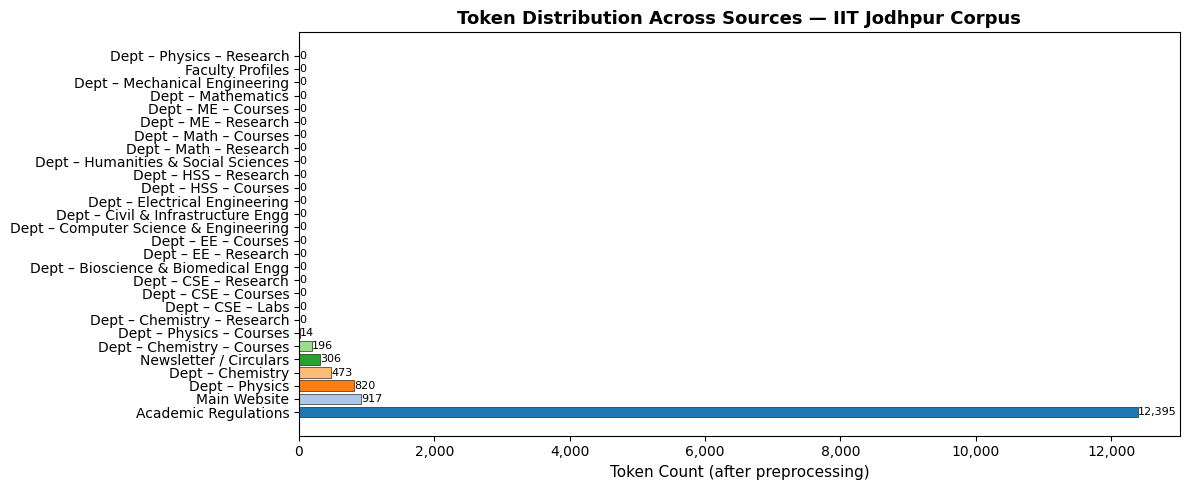

Bar chart saved => data/token_distribution.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

# Aggregate all clean tokens
all_tokens = [tok for toks in df['tokens_clean'] for tok in toks]
vocab      = set(all_tokens)
freq       = Counter(all_tokens)

total_docs   = len(df)
total_tokens = len(all_tokens)
vocab_size   = len(vocab)

print('╔══════════════════════════════════════════╗')
print('║        CORPUS STATISTICS REPORT          ║')
print('╠══════════════════════════════════════════╣')
print(f'║  Total documents (pages)  : {total_docs:<13} ║')
print(f'║  Total tokens (clean)     : {total_tokens:<13,} ║')
print(f'║  Vocabulary size          : {vocab_size:<13,} ║')
print(f'║  Avg tokens per document  : {total_tokens//total_docs:<13,} ║')
print('╚══════════════════════════════════════════╝')

df['clean_token_count'] = df['tokens_clean'].apply(len)
src_stats = (
    df.groupby('source_name')['clean_token_count']
    .sum()
    .sort_values(ascending=False)
)

short_labels = [s.replace('Department ', 'Dept ') for s in src_stats.index]

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab20.colors
bars = ax.barh(short_labels, src_stats.values,
               color=colors[:len(src_stats)], edgecolor='black', linewidth=0.4)
ax.set_xlabel('Token Count (after preprocessing)', fontsize=11)
ax.set_title('Token Distribution Across Sources — IIT Jodhpur Corpus',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, src_stats.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/token_distribution.png', dpi=150)
plt.show()
print('Bar chart saved => data/token_distribution.png')

# Here I am computing comprehensive corpus statistics and visualizing token distribution across all sources


=== Top-50 Most Frequent Content Words (stopwords excluded) ===
              Word  Frequency
1          student        215
2           course        140
3         students        118
4         academic        102
5          program        100
6         semester         94
7           degree         91
8          credits         88
9          courses         82
10    requirements         78
11             may         73
12        research         67
13      department         60
14           grade         57
15         minimum         56
16       institute         54
17      supervisor         54
18         jodhpur         51
19           shall         51
20            must         49
21    registration         48
22         regular         47
23             iit         46
24            dual         46
25     examination         45
26     engineering         42
27          senate         42
28          thesis         39
29            dean         38
30         science         37
31    

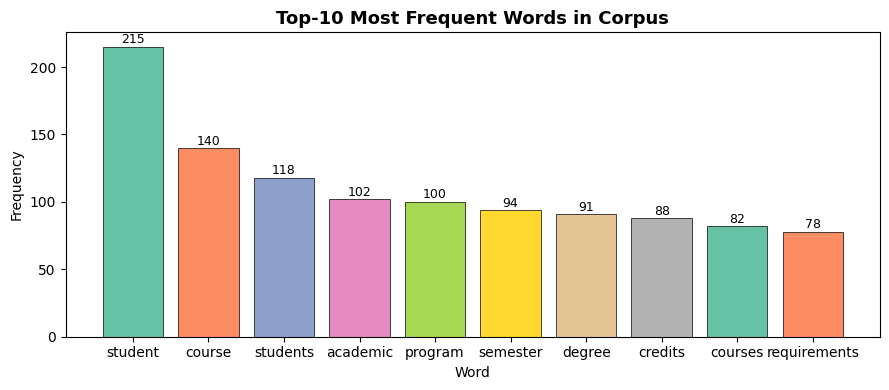

Top-10 chart saved => data/top10_words.png


In [ ]:
content_tokens = [t for t in all_tokens if t not in ENGLISH_STOPWORDS]
content_freq   = Counter(content_tokens)

top50 = content_freq.most_common(50)
freq_df = pd.DataFrame(top50, columns=['Word', 'Frequency'])
freq_df.index += 1

print('=== Top-50 Most Frequent Content Words (stopwords excluded) ===')
print(freq_df.to_string())

# Top-10 bar chart
top10 = freq_df.head(10)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(top10['Word'], top10['Frequency'],
       color=plt.cm.Set2.colors[:10], edgecolor='black', linewidth=0.5)
ax.set_title('Top-10 Most Frequent Words in Corpus', fontsize=13, fontweight='bold')
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
for i, v in enumerate(top10['Frequency']):
    ax.text(i, v + 0.3, str(v), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('data/top10_words.png', dpi=150)
plt.show()
print('Top-10 chart saved => data/top10_words.png')

# Here I am analyzing word frequency distribution and creating visualizations for top-10 and top-50 most frequent content words


## Step 21 – Word Cloud of Most Frequent Words

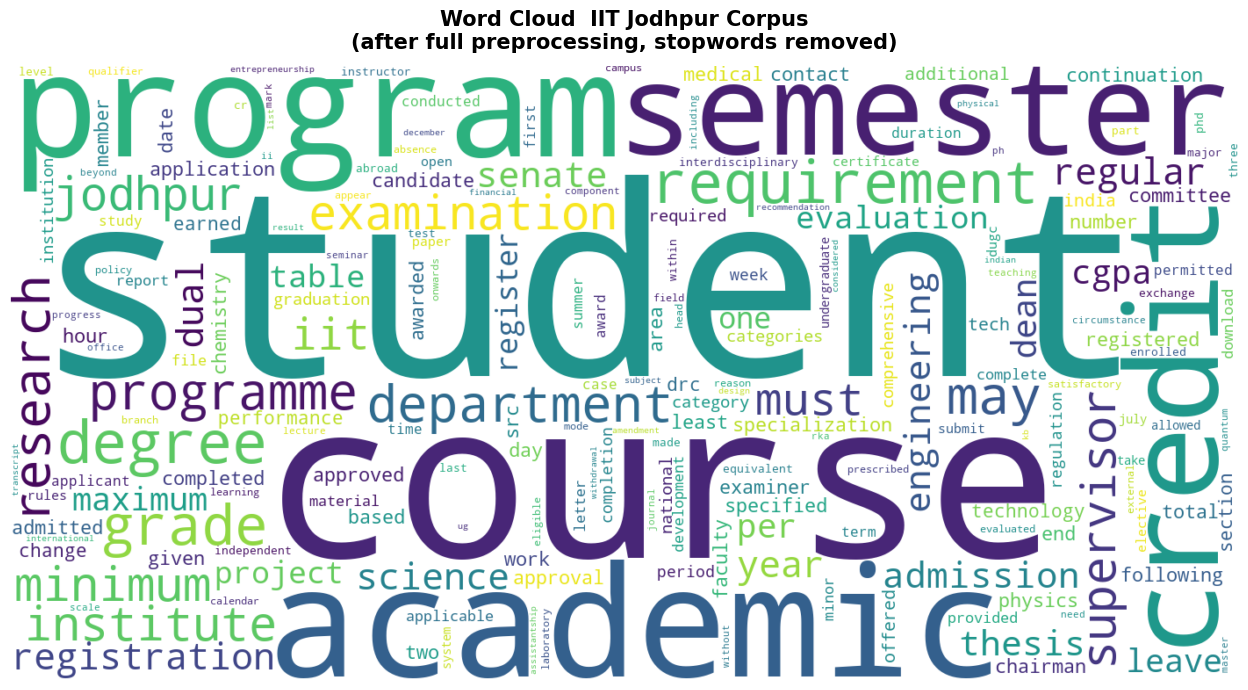

Word cloud saved => data/wordcloud.png


In [ ]:
from wordcloud import WordCloud

wc_text = ' '.join(content_tokens)

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='viridis',
    max_words=200,
    min_font_size=8,
    prefer_horizontal=0.75,
    collocations=False,
).generate(wc_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Word Cloud  IIT Jodhpur Corpus\n(after full preprocessing, stopwords removed)',
    fontsize=15, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig('data/wordcloud.png', dpi=200, bbox_inches='tight')
plt.show()
print('Word cloud saved => data/wordcloud.png')

# Here I am generating a word cloud visualization of the most frequent content words from the entire corpus


## Step 22 – Save Clean Preprocessed Corpus

In [ ]:
import json as _json

# 1. CSV
save_cols = ['source_id', 'source_name', 'url', 'text_clean', 'clean_token_count']
clean_csv = 'data/iitj_corpus_clean.csv'
df[save_cols].to_csv(clean_csv, index=False, encoding='utf-8')
print(f'Clean CSV saved => {clean_csv}')

# 2. Plain text
clean_txt = 'data/iitj_corpus_clean.txt'
with open(clean_txt, 'w', encoding='utf-8') as f:
    for _, row in df.iterrows():
        f.write(f'=== SOURCE: {row["source_name"]} | URL: {row["url"]} ===\n')
        f.write(row['text_clean'])
        f.write('\n\n')
print(f'Clean TXT saved => {clean_txt}')

# 3. JSON token arrays
clean_json = 'data/iitj_tokens.json'
recs = [
    {'source_name': row['source_name'], 'url': row['url'], 'tokens': row['tokens_clean']}
    for _, row in df.iterrows()
]
with open(clean_json, 'w', encoding='utf-8') as f:
    _json.dump(recs, f, indent=2, ensure_ascii=False)
print(f'Token JSON saved => {clean_json}')

print('\n=== Final Preprocessed Corpus Summary ===')
print(f'  Documents      : {total_docs}')
print(f'  Total tokens   : {total_tokens:,}')
print(f'  Vocabulary size: {vocab_size:,}')
print('\nAll preprocessing complete!')

# Here I am saving the final clean and preprocessed corpus to CSV, plain text, and JSON token array formats


Clean CSV saved => data/iitj_corpus_clean.csv
Clean TXT saved => data/iitj_corpus_clean.txt
Token JSON saved => data/iitj_tokens.json

=== Final Preprocessed Corpus Summary ===
  Documents      : 68
  Total tokens   : 15,121
  Vocabulary size: 2,214

All preprocessing complete!
